In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df=pd.read_csv('/content/INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8 - INX_Future_Inc_Employee_Perform.csv')
pd.set_option('display.max_columns',None)

# Domain Analysis
* Employee performance reflects productivity, goal achievement, and overall contribution to the organization.

* Performance is typically influenced by multiple factors such as compensation, work environment, career growth, job satisfaction, and employee engagement.

* Compensation-related variables (e.g., EmpLastSalaryHikePercent, EmpHourlyRate) represent recognition and financial motivation, which are expected to positively influence performance.

* Satisfaction-related variables (EmpEnvironmentSatisfaction, EmpJobSatisfaction, EmpRelationshipSatisfaction) indicate employee engagement levels, which directly impact productivity.

* Career growth indicators such as YearsSinceLastPromotion and EmpJobLevel reflect progression opportunities. Longer stagnation may negatively affect motivation and performance.

* Experience-related variables (TotalWorkExperienceInYears, ExperienceYearsAtThisCompany, ExperienceYearsInCurrentRole) represent employee tenure and stability. However, excessive role stagnation may reduce performance growth.

* Department and Job Role are important as performance expectations vary across functions such as Sales, Development, and Research.

* Work-life balance and overtime can influence employee well-being, which may indirectly affect performance levels.

* Predicting PerformanceRating helps HR identify key performance drivers and design data-driven strategies for employee development and retention.


# Data Understanding

In [38]:
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3


In [39]:
df.tail()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,4,71,4,2,4,1,Yes,20,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,4,80,4,1,4,3,No,17,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,4,74,4,1,3,1,Yes,11,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,4,46,2,3,2,1,No,14,2,9,3,4,8,7,7,7,No,3
1199,E100998,24,Female,Life Sciences,Single,Sales,Sales Executive,Travel_Rarely,3,2,1,65,3,2,3,9,No,14,1,4,3,3,2,2,2,0,Yes,2


In [40]:
df.shape

(1200, 28)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [42]:
df.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


In [43]:
df.describe(include='object')

,EmpNumber,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,OverTime,Attrition
count,1200,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,2,6,3,6,19,3,2,2
top,E100967,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Rarely,No,No
freq,1,725,492,548,373,270,846,847,1022


In [44]:
df.isnull().sum()

,0
EmpNumber,0
Age,0
Gender,0
EducationBackground,0
MaritalStatus,0
EmpDepartment,0
EmpJobRole,0
BusinessTravelFrequency,0
DistanceFromHome,0
EmpEducationLevel,0


# Summary
* The dataset contains 1200 rows and 28 columns, representing employee records and related attributes.

### df.head() and df.tail()
* were used to verify correct data loading, column names, and overall structure.

### df.info() revealed:

* 19 numerical columns (int64)

* 9 categorical columns (object)

* No missing values in any column

### df.describe() showed:

* Age and experience-related variables are within realistic working population ranges.

* Experience variables show slightly right-skewed distributions.

* Salary hike percentage varies within a reasonable increment range.

* PerformanceRating contains only values 2, 3, and 4.

### df.describe(include='object') indicated:

* Majority employees belong to certain departments such as Sales and Development.

* Most employees travel rarely for business.

* OverTime is mostly marked as “No”.

### df.isnull().sum()
* confirmed that there are no missing values in the dataset.

Overall, the dataset is clean, structured, and ready for preprocessing and analysis.

# Exploratory Data Analysis
## 1. Univariate Analysis

In [45]:
num_cols = []

for col in df.columns:
    if df[col].dtype != 'object':
        num_cols.append(col)

print(num_cols)

['Age', 'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked', 'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear', 'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'PerformanceRating']


In [46]:
cat_cols = []
for col in df.columns:
  if df[col].dtype == 'object':
    cat_cols.append(col)
cat_cols.remove('EmpNumber')
print(cat_cols)

['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition']


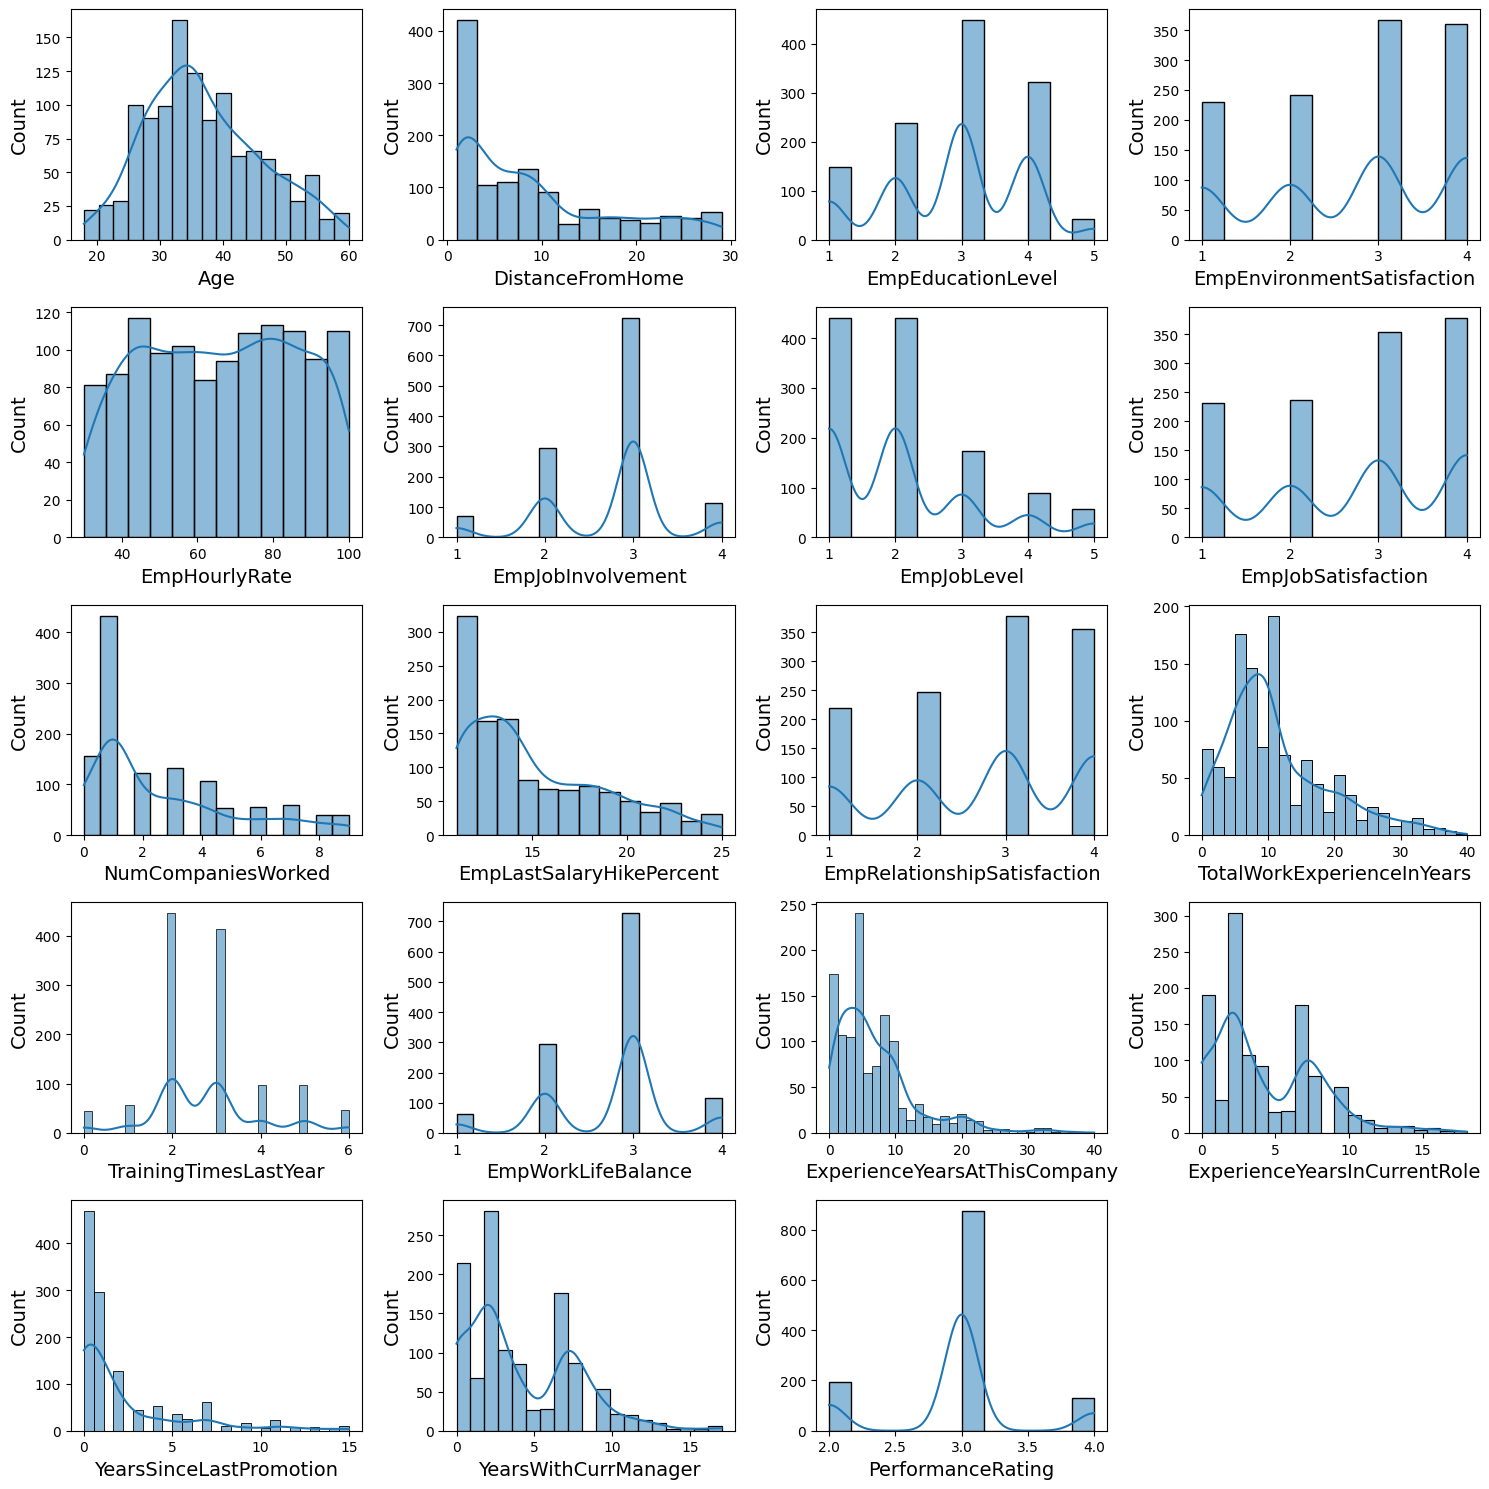

In [47]:
plt.figure(figsize=(15,15),facecolor='white')
plotnum = 1
for i in num_cols:
  if plotnum <= 20:
    plt.subplot(5,4,plotnum)
    sns.histplot(df[i],kde=True)
    plt.xlabel(i,fontsize=14)
    plt.ylabel('Count',fontsize=14)
  plotnum = plotnum + 1
plt.tight_layout()
plt.show()

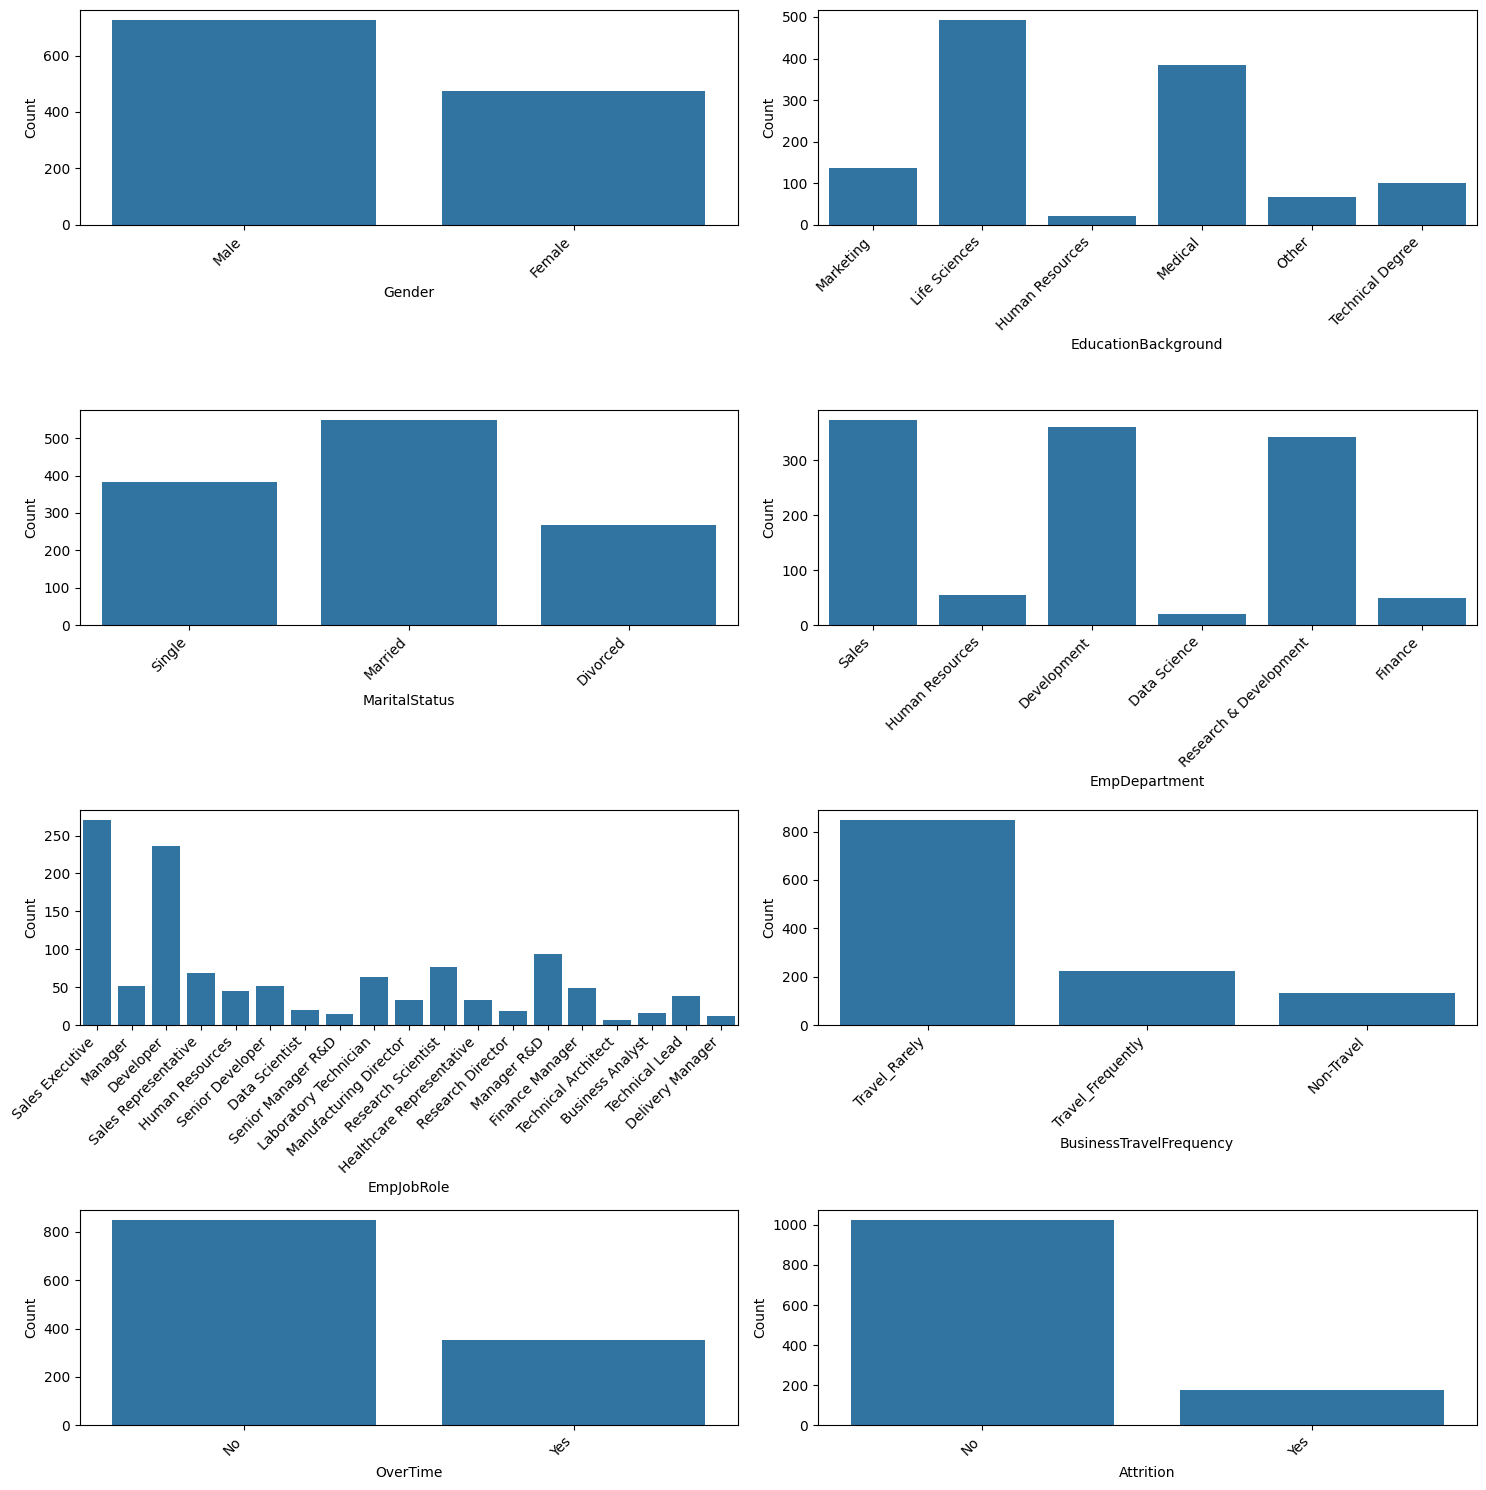

In [48]:
plt.figure(figsize=(15,15),facecolor='white')
plotnum = 1
for i in cat_cols:
  if plotnum <= 8:
    plt.subplot(4,2,plotnum)
    sns.countplot(x=i,data=df)
    plt.xlabel(i,fontsize=10)
    plt.ylabel('Count',fontsize=10)
    plt.xticks(rotation=45, ha='right')
  plotnum = plotnum + 1
plt.tight_layout()
plt.show()

# Summary

### Numerical Columns:
* Age: roughly bell-shaped (peak 30-40) → workforce concentrated in mid-career; use age-stratified retention policies.

* DistanceFromHome: right-skewed (most live nearby, few long commuters) → commuting burden may affect retention for tail group.

* EmpHourlyRate: multi-modal / banded (pay bands) → salary bands map to roles/levels; include level in compensation analyses.

* TotalWorkExperienceInYears: right-skewed (many with low experience, long tail) → many junior hires; training impact important.

* YearsSinceLastPromotion: right-skewed with many 0-2 yrs; longer gaps associate with lower performance → promotion lag is a risk factor.

* EmpLastSalaryHikePercent: clustered at common hike values, mild right-skew; higher hikes align with higher performance → compensation signal matters.

* NumCompaniesWorked: right-skewed (many low values) → workforce is reasonably stable historically; use for attrition modeling.

* EmpEnvironmentSatisfaction (1-4 scale): concentrated 3-4 with strong positive correlation to performance → environment improvement likely improves performance.

### Categorical Columns:
* EmpDepartment: Sales & Development largest; Finance smaller; Finance & Sales show higher share of low performers → prioritize departmental interventions.

* EmpJobRole: high-cardinality (many roles) → group rare roles or use target encoding; visualize horizontally.

* Gender: more Males than Females (imbalance not extreme) → check role/level gender splits for equity interventions.

* OverTime: majority No; minority Yes; surprisingly, overtime shows slightly higher mean performance — interpret carefully (may reflect high-performers doing extra work).

* BusinessTravelFrequency: mostly Travel_Rarely; few Travel_Frequently → travel policies likely not a major driver overall.

* Attrition: low (~15%); leaving employees have slightly lower mean performance — consider engagement/promo signals for retention.

##2. Bivariate Analysis

In [49]:
num_cols2 = ['Age','DistanceFromHome','EmpEducationLevel','EmpEnvironmentSatisfaction','EmpHourlyRate','EmpJobInvolvement',
             'EmpJobLevel','EmpJobSatisfaction','NumCompaniesWorked','EmpLastSalaryHikePercent','EmpRelationshipSatisfaction',
             'TotalWorkExperienceInYears','TrainingTimesLastYear','EmpWorkLifeBalance','ExperienceYearsAtThisCompany',
             'ExperienceYearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']

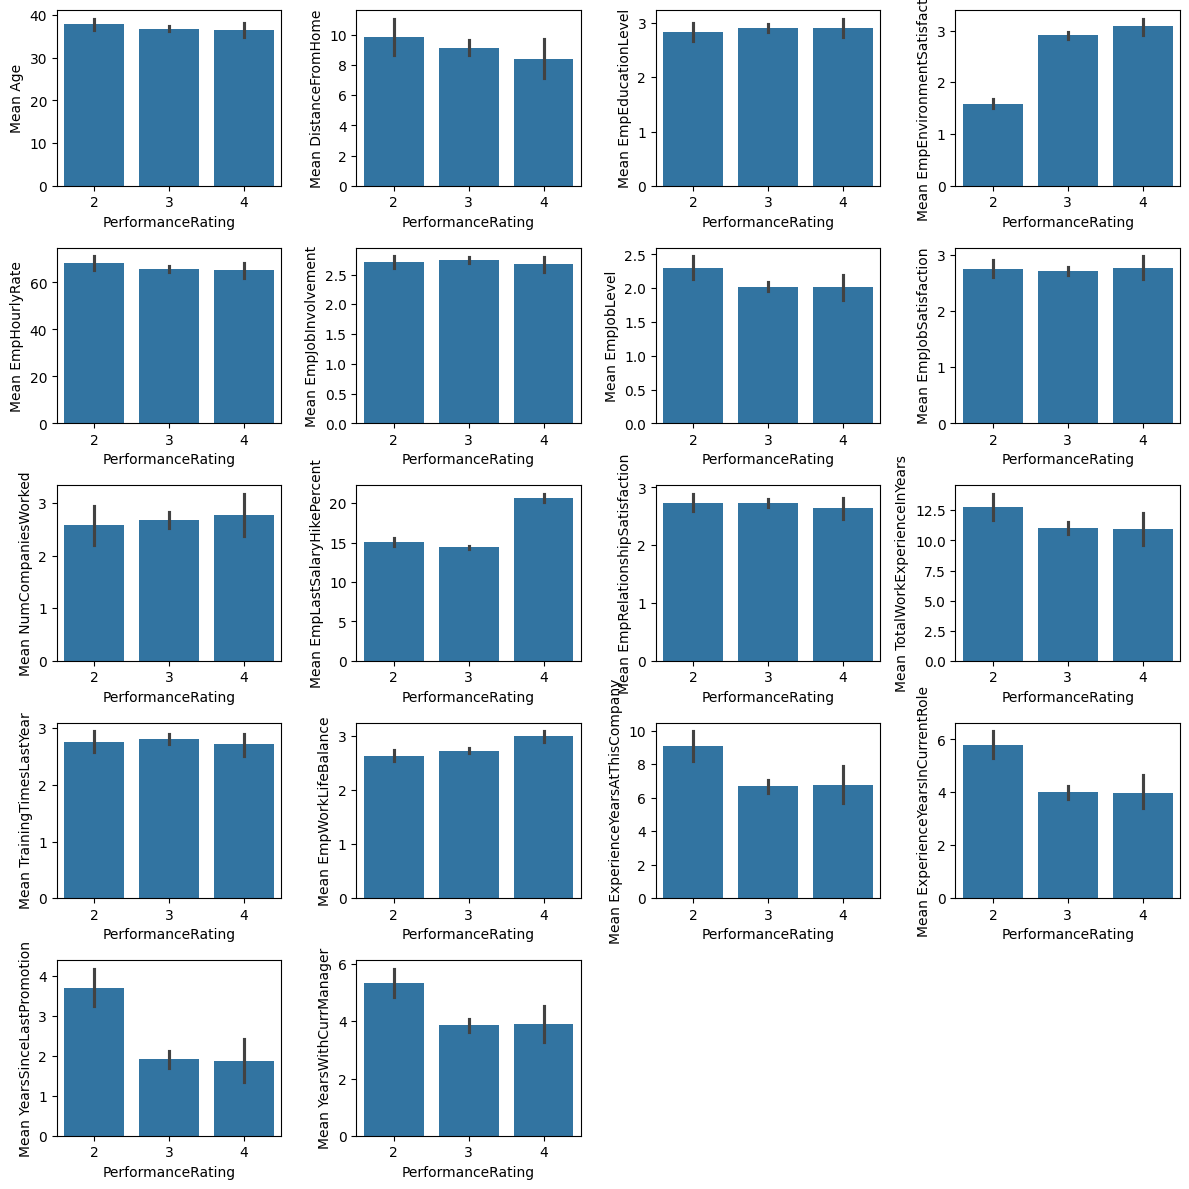

In [50]:
plt.figure(figsize=(12,12))

for i,col in enumerate(num_cols2[:18],1):
    plt.subplot(5,4,i)
    sns.barplot(x='PerformanceRating', y=col, data=df)
    plt.xlabel('PerformanceRating')
    plt.ylabel(f'Mean {col}')

plt.tight_layout()
plt.show()

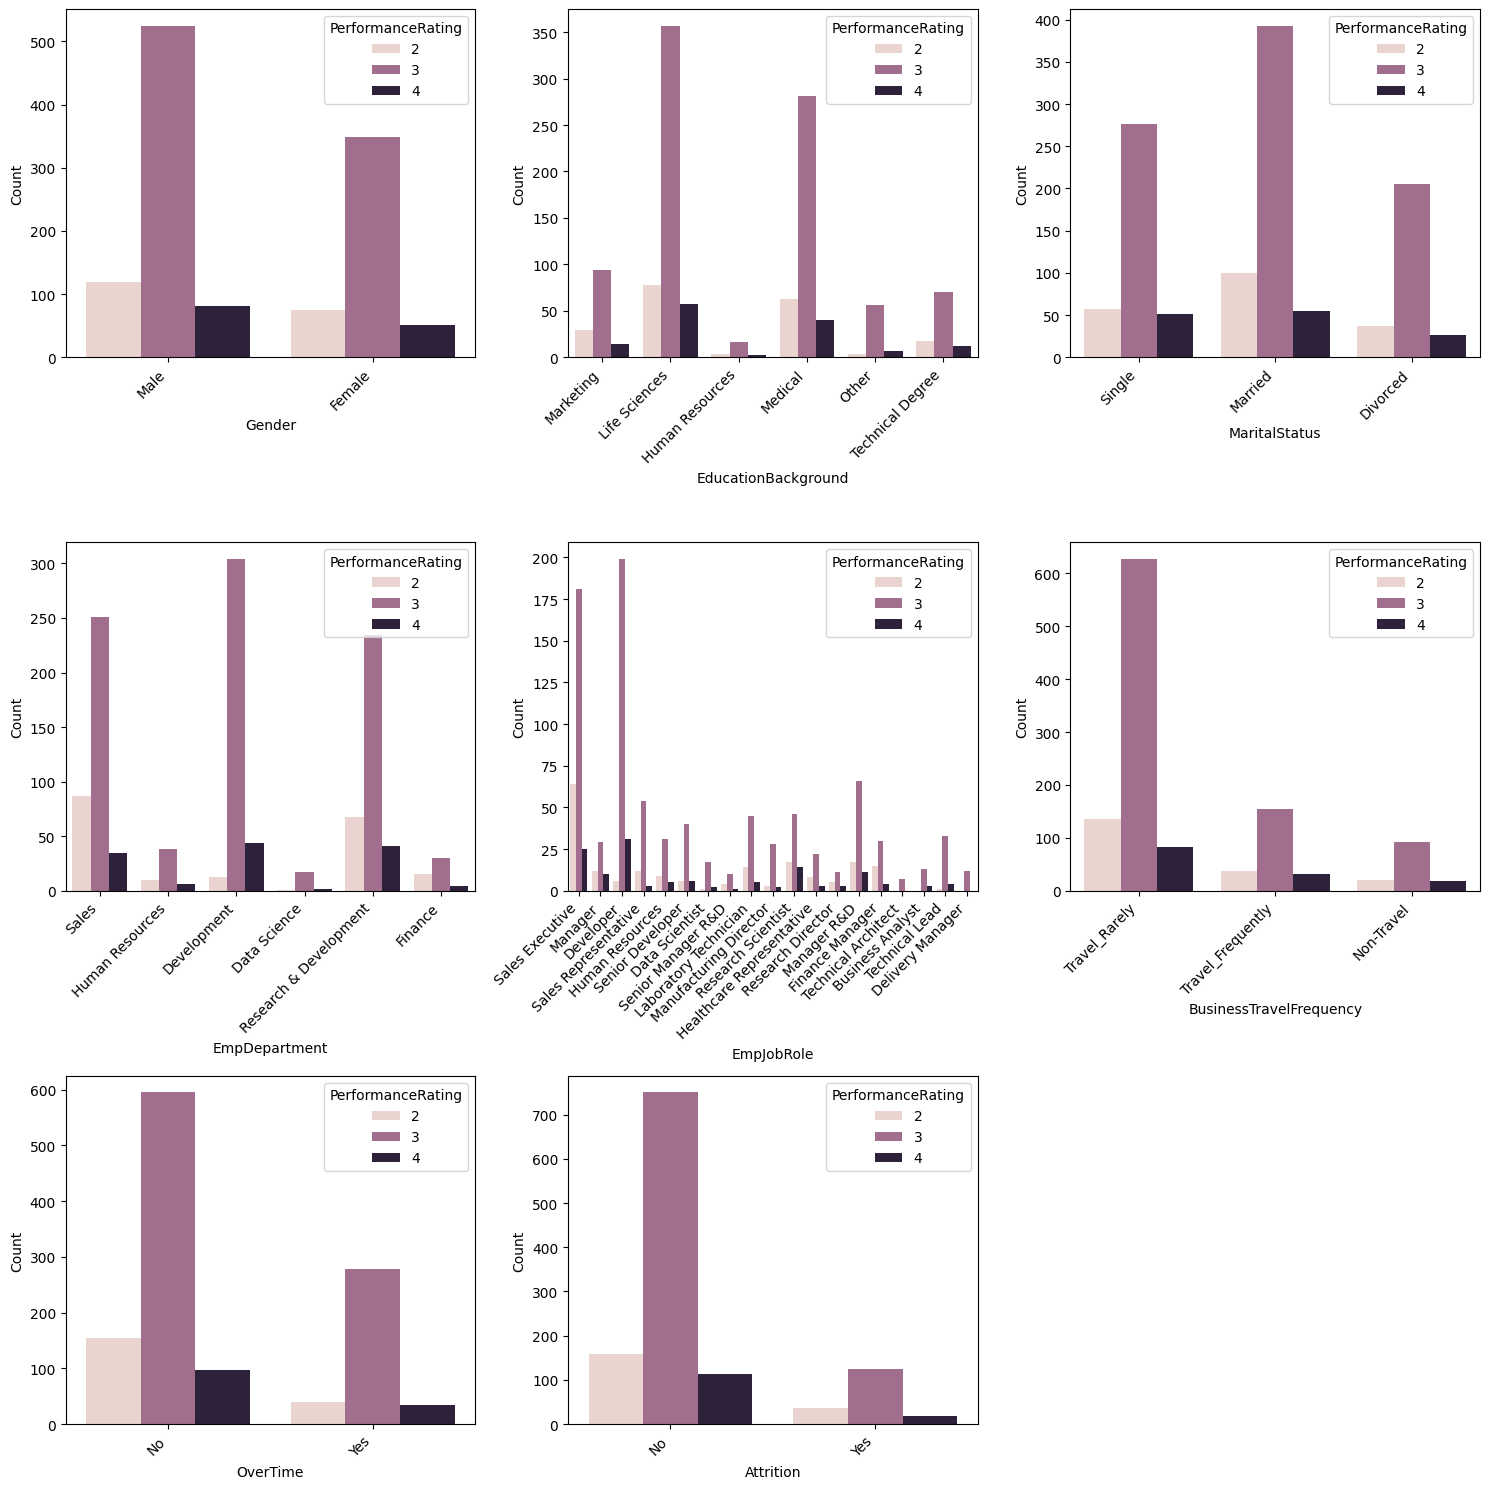

In [51]:
plt.figure(figsize=(15,15), facecolor='white')

plotnum = 1

for col in cat_cols:
    if plotnum <= 9:
        plt.subplot(3,3,plotnum)
        sns.countplot(x=col, hue='PerformanceRating', data=df)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel(col)
        plt.ylabel('Count')
        plotnum += 1

plt.tight_layout()
plt.show()

# Summary
##Numerical Variables vs PerformanceRating

* EmpEnvironmentSatisfaction increases with higher PerformanceRating. Employees rated 4 have clearly higher mean satisfaction compared to rating 2. This shows a strong positive relationship between work environment and performance.

* EmpLastSalaryHikePercent increases significantly as PerformanceRating increases. Employees with rating 4 receive higher salary hikes, indicating compensation plays a major role in performance.

* YearsSinceLastPromotion decreases as PerformanceRating increases. Employees with long promotion gaps tend to have lower performance ratings.

* ExperienceYearsAtThisCompany is slightly lower for higher performers. Employees with very long tenure may show performance plateau.

* ExperienceYearsInCurrentRole is lower for higher ratings. Staying too long in the same role may reduce growth and performance.

* TotalWorkExperienceInYears shows a slight negative trend with higher ratings. Mid-career employees appear more performance-driven.

* EmpWorkLifeBalance increases with PerformanceRating. Better balance is associated with better performance.

* Age and DistanceFromHome do not show strong variation across performance levels. These variables are weak predictors of performance.

* EmpHourlyRate does not show strong variation across performance categories.

* EmpJobInvolvement and EmpJobSatisfaction show slight positive trend with higher ratings but not very strong.

* EmpJobLevel increases slightly with performance but variation is moderate.

* EmpRelationshipSatisfaction shows minimal difference across performance levels.

* NumCompaniesWorked and TrainingTimesLastYear do not show strong separation between ratings.

* YearsWithCurrManager shows slight variation but no strong pattern.


##Categorical Variables vs PerformanceRating

* Department shows noticeable variation. Finance and Sales departments have a higher proportion of rating 2 employees, while Development and Data Science have more rating 3 and 4 employees.

* JobRole shows uneven distribution of performance ratings. Some roles such as Sales Executive show more low performers compared to technical roles.

* OverTime does not show a strong negative impact on performance. Most overtime employees still fall under rating 3.

* Attrition shows that employees who left have slightly higher proportion of lower performance ratings.

* BusinessTravelFrequency does not show strong separation between performance classes.

* Gender shows similar performance distribution across male and female employees, indicating no major gender-based performance gap.

* MaritalStatus does not show strong impact on performance. Distribution is fairly consistent across categories.

##3. Multivariate Analysis

* Here we will see only important numerical columns

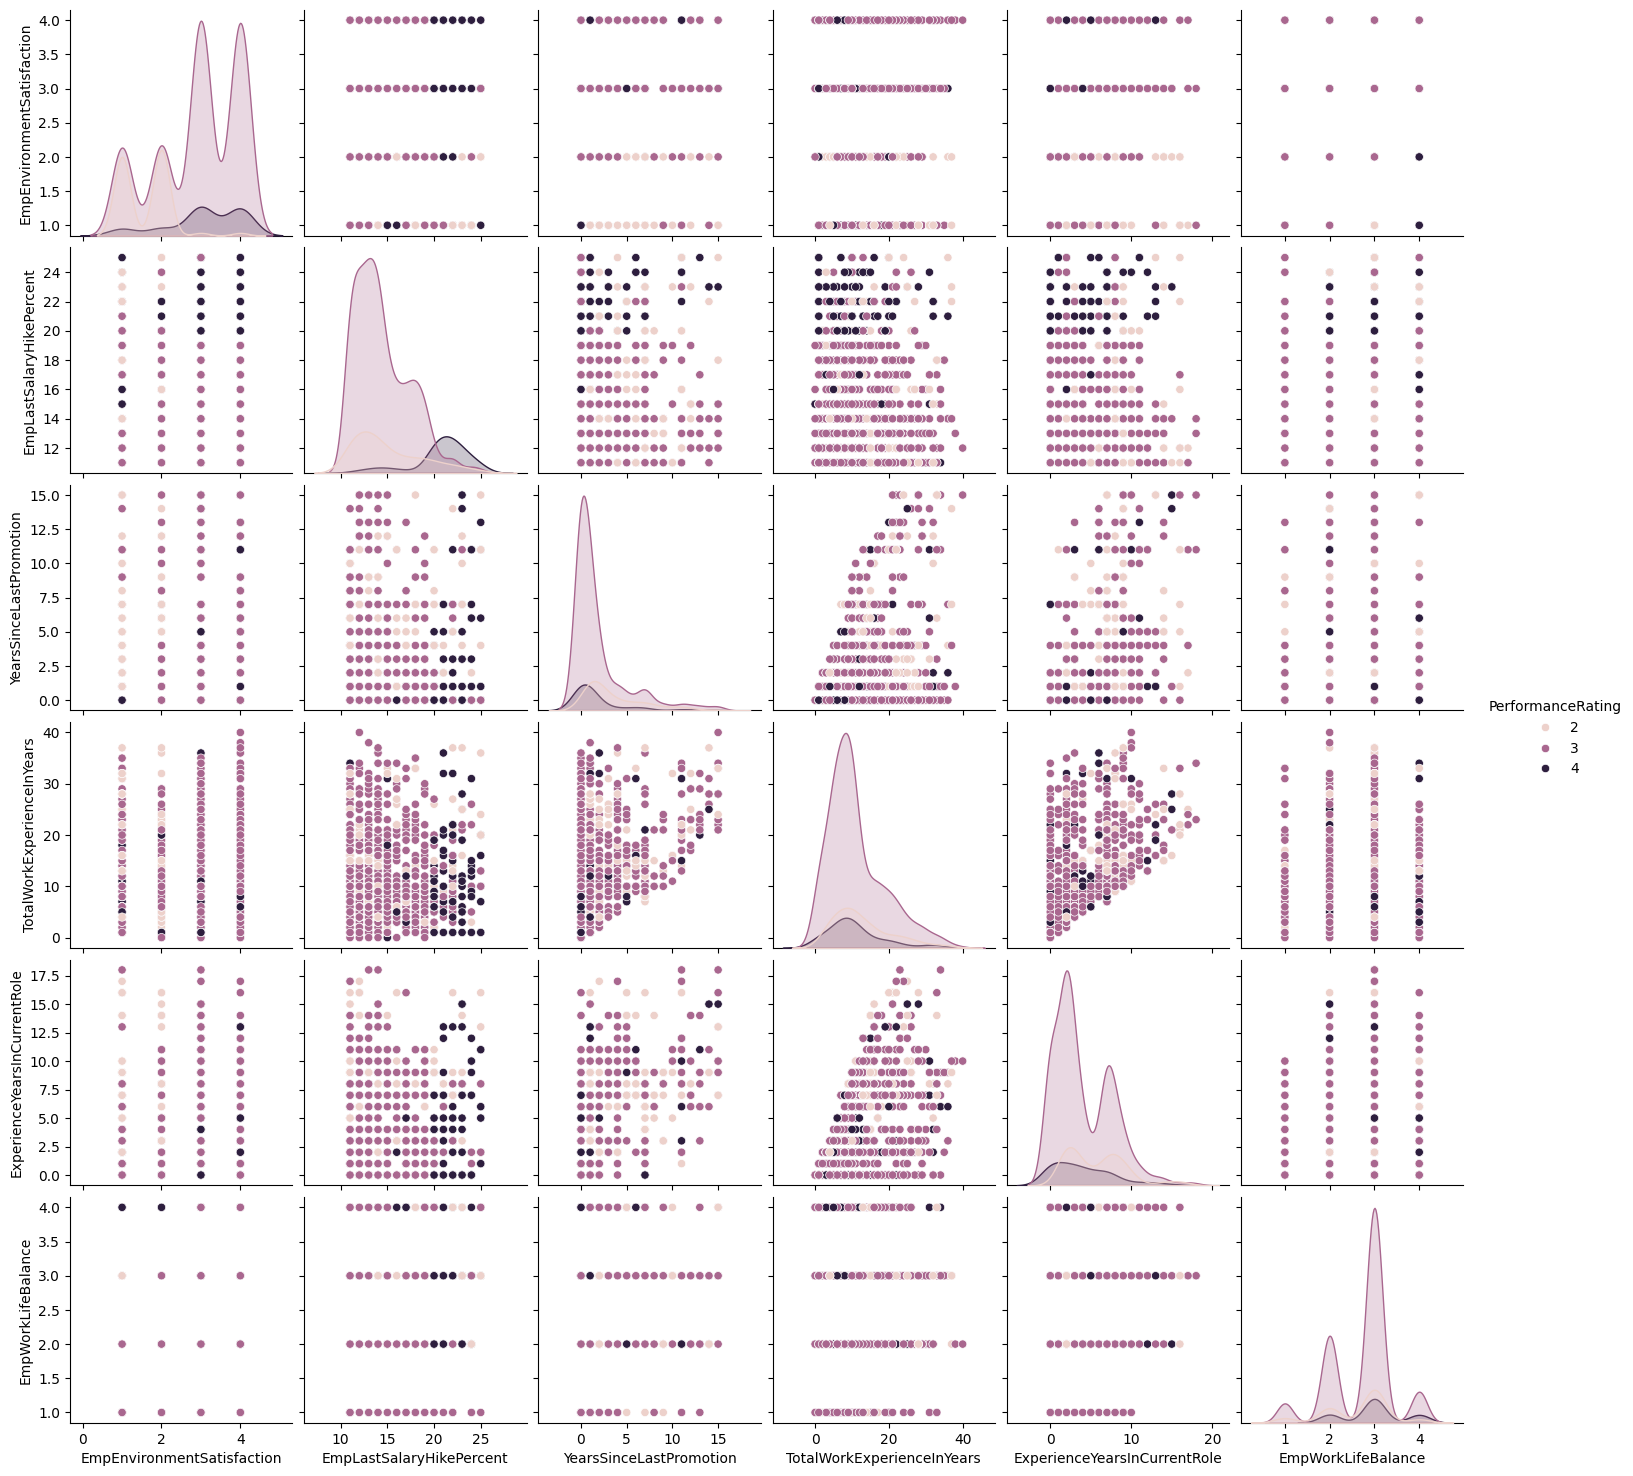

In [52]:
pair_cols = [
    'EmpEnvironmentSatisfaction',
    'EmpLastSalaryHikePercent',
    'YearsSinceLastPromotion',
    'TotalWorkExperienceInYears',
    'ExperienceYearsInCurrentRole',
    'EmpWorkLifeBalance'
]

sns.pairplot(df[pair_cols + ['PerformanceRating']],
             hue='PerformanceRating',
             diag_kind='kde')

plt.show()

## Department-wise performance distribution


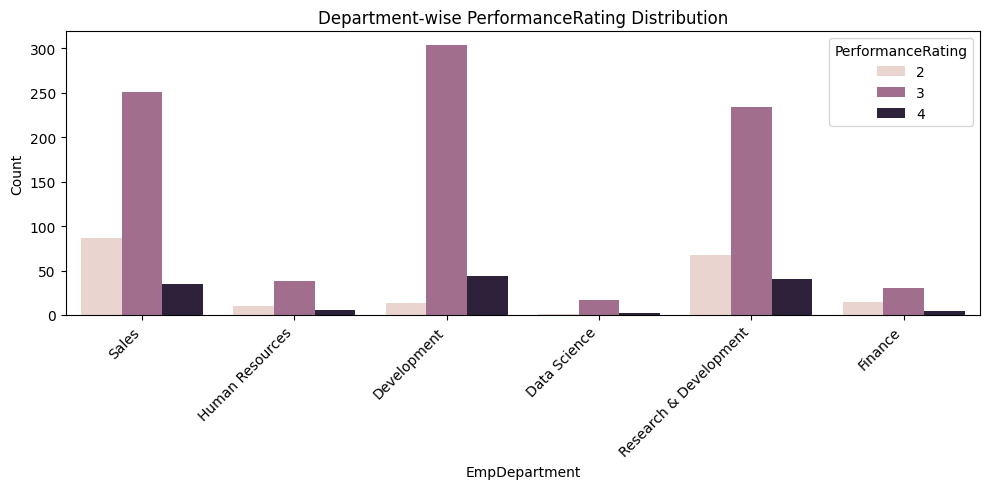

In [53]:
plt.figure(figsize=(10,5))
sns.countplot(x='EmpDepartment', hue='PerformanceRating', data=df)
plt.xticks(rotation=45, ha='right')
plt.xlabel('EmpDepartment')
plt.ylabel('Count')
plt.title('Department-wise PerformanceRating Distribution')
plt.tight_layout()
plt.show()

# Summary
* EmpEnvironmentSatisfaction shows clear separation across performance classes. Employees with rating 4 are concentrated at higher satisfaction levels, confirming it as a strong performance driver.

* EmpLastSalaryHikePercent shows visible upward shift for higher ratings. Rating 4 employees cluster in higher salary hike ranges, indicating compensation strongly influences performance.

* YearsSinceLastPromotion shows inverse relationship with performance. Lower promotion gap is associated with higher performance ratings.

* TotalWorkExperienceInYears and ExperienceYearsInCurrentRole show positive relationship with each other, indicating natural career progression pattern.

* ExperienceYearsInCurrentRole and YearsSinceLastPromotion are positively correlated, meaning employees staying longer in same role also tend to have longer promotion gaps.

* EmpWorkLifeBalance shows moderate separation across performance classes. Higher ratings tend to cluster at balance level 3 and 4.

* Salary hike percentage and Environment Satisfaction together show clearer separation for rating 4 employees, suggesting combined impact of recognition and work environment.

* No strong linear relationship is observed between Age and other major performance drivers in this selected pairplot.

* Most relationships appear moderately correlated rather than strongly linear, indicating performance is influenced by multiple interacting factors rather than a single dominant variable.


# Data Preprocessing

#### We will check outliers in important numerical columns

In [54]:
check_outliers = ['EmpHourlyRate','EmpLastSalaryHikePercent','TotalWorkExperienceInYears','YearsSinceLastPromotion',
                  'ExperienceYearsAtThisCompany','ExperienceYearsInCurrentRole','DistanceFromHome','NumCompaniesWorked','Age']

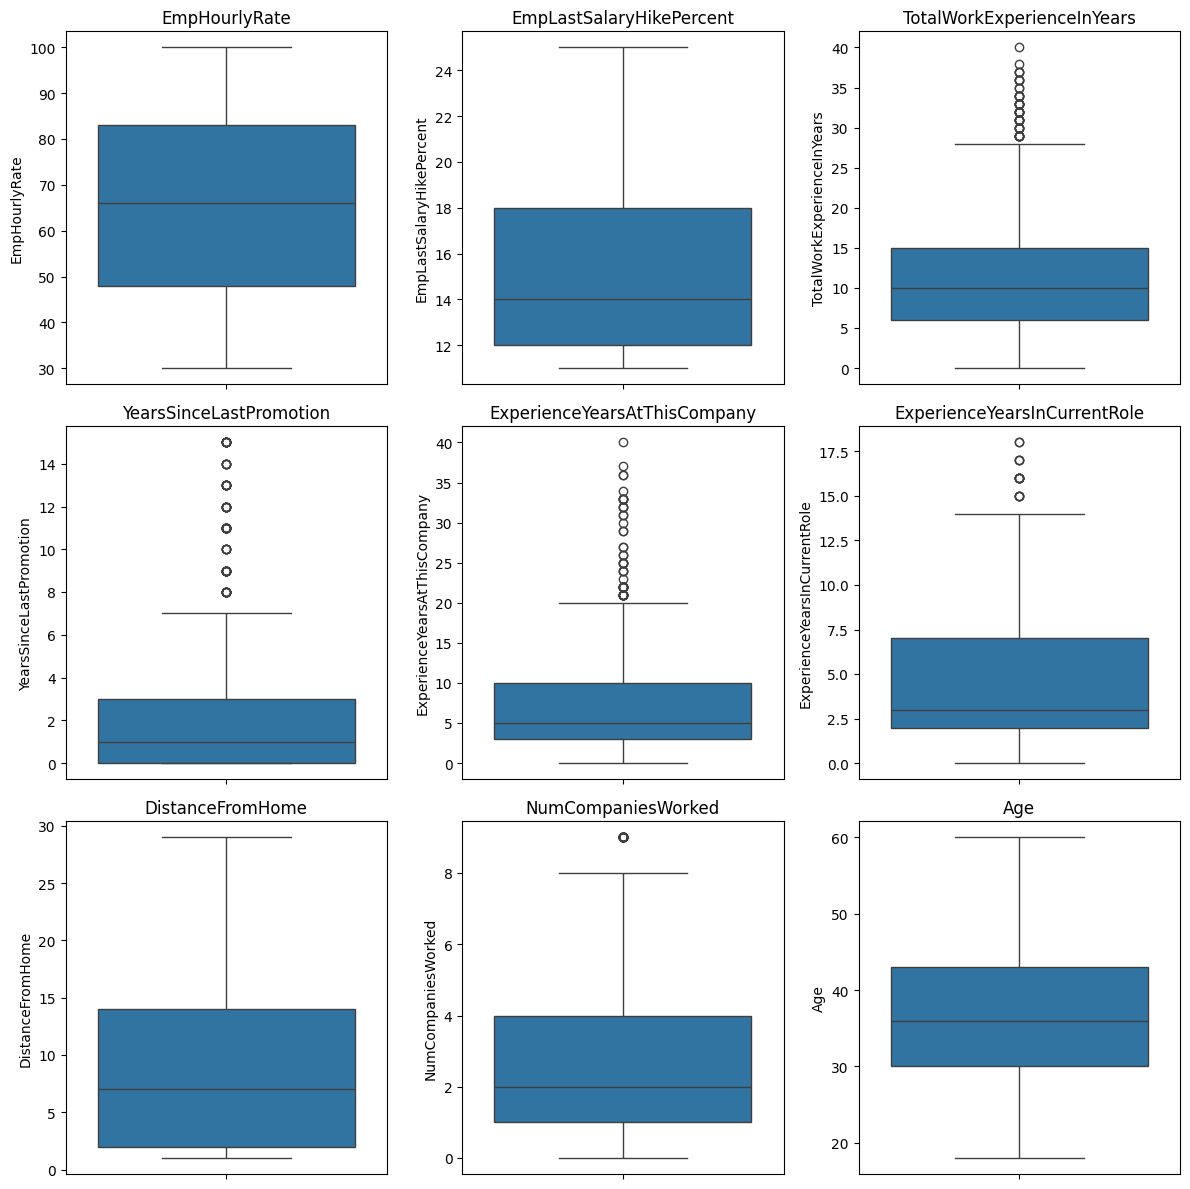

In [55]:
plt.figure(figsize=(12,12), facecolor='white')
plotnum = 1

for col in check_outliers:
    if plotnum <= 9:
        plt.subplot(3,3,plotnum)
        sns.boxplot(y=df[col])
        plt.title(col)
        plotnum += 1

plt.tight_layout()
plt.show()

In [56]:
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3


* First of all we will drop unnecessary columns

In [57]:
df.drop(['EmpNumber'],axis=1,inplace=True)

* Now we will apply one hot encoding for binary to numerical conversion.

In [58]:
df=pd.get_dummies(df,columns=['Gender','EducationBackground','EmpDepartment','EmpJobRole','OverTime','BusinessTravelFrequency','Attrition','MaritalStatus'],drop_first=True,dtype=int)

In [59]:
df.dtypes.value_counts()

,count
int64,54


In [60]:
df.head(1)

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating,Gender_Male,EducationBackground_Life Sciences,EducationBackground_Marketing,EducationBackground_Medical,EducationBackground_Other,EducationBackground_Technical Degree,EmpDepartment_Development,EmpDepartment_Finance,EmpDepartment_Human Resources,EmpDepartment_Research & Development,EmpDepartment_Sales,EmpJobRole_Data Scientist,EmpJobRole_Delivery Manager,EmpJobRole_Developer,EmpJobRole_Finance Manager,EmpJobRole_Healthcare Representative,EmpJobRole_Human Resources,EmpJobRole_Laboratory Technician,EmpJobRole_Manager,EmpJobRole_Manager R&D,EmpJobRole_Manufacturing Director,EmpJobRole_Research Director,EmpJobRole_Research Scientist,EmpJobRole_Sales Executive,EmpJobRole_Sales Representative,EmpJobRole_Senior Developer,EmpJobRole_Senior Manager R&D,EmpJobRole_Technical Architect,EmpJobRole_Technical Lead,OverTime_Yes,BusinessTravelFrequency_Travel_Frequently,BusinessTravelFrequency_Travel_Rarely,Attrition_Yes,MaritalStatus_Married,MaritalStatus_Single
0,32,10,3,4,55,3,2,4,1,12,4,10,2,2,10,7,0,8,3,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1


# Summary
* Dropped non-informative identifier column EmpNumber since it does not contribute to predicting performance and can add noise.

* Checked for missing values using df.isnull().sum() and found no missing values in the dataset, so no imputation was required.

* Verified data types using df.info():

* Numerical features were already in integer format.

* Categorical features were stored as object type and needed encoding.

* Target variable PerformanceRating was inspected using value_counts():

* The dataset contains classes 2, 3, and 4 only; class 1 has zero occurrences.

* Due to class imbalance, stratified train-test split was used during modeling.

* Categorical variables were converted into numeric format using One-Hot Encoding (pd.get_dummies) with drop_first=True to avoid dummy variable trap.

* Confirmed the encoded dataset contains only numeric columns (0/1 for dummy variables), making it suitable for machine learning models.

* Outlier analysis was performed for continuous numerical variables using boxplots and IQR logic.

* Outliers were mainly observed in experience and promotion-related features (e.g., TotalWorkExperienceInYears, YearsSinceLastPromotion).

* These values represent realistic senior employees and long promotion gaps rather than data errors.

* Therefore, no outlier removal was applied to avoid losing meaningful business information.

* Final dataset after preprocessing was ready for feature selection and model building.

### Heatmap

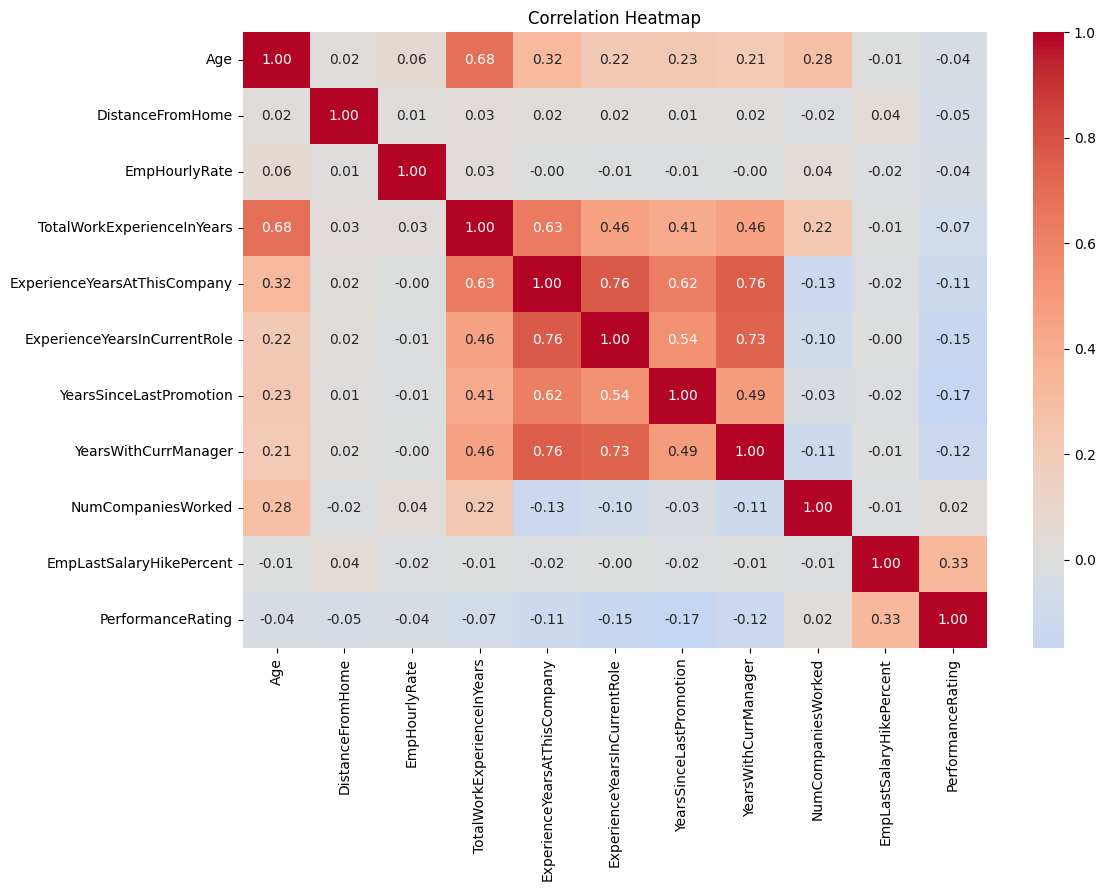

In [61]:
num_cols = [
    'Age','DistanceFromHome','EmpHourlyRate',
    'TotalWorkExperienceInYears','ExperienceYearsAtThisCompany',
    'ExperienceYearsInCurrentRole','YearsSinceLastPromotion',
    'YearsWithCurrManager','NumCompaniesWorked',
    'EmpLastSalaryHikePercent'
]

plt.figure(figsize=(12,8))
corr = df[num_cols + ['PerformanceRating']].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

* Correlation analysis shows that EmpLastSalaryHikePercent has the strongest positive relationship with PerformanceRating. Experience and promotion-related variables show moderate negative correlation with performance, indicating that longer stagnation in role or promotion gap may reduce employee performance. Several experience-related variables are highly correlated with each other, indicating multicollinearity among tenure-based features.

### Feature Importance

In [62]:
X = df.drop('PerformanceRating', axis=1)
y = df['PerformanceRating']

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.head(10))

EmpLastSalaryHikePercent        0.181855
EmpEnvironmentSatisfaction      0.166072
YearsSinceLastPromotion         0.081694
EmpHourlyRate                   0.039972
ExperienceYearsInCurrentRole    0.038940
Age                             0.037169
ExperienceYearsAtThisCompany    0.034534
YearsWithCurrManager            0.032363
TotalWorkExperienceInYears      0.030865
DistanceFromHome                0.030336
dtype: float64


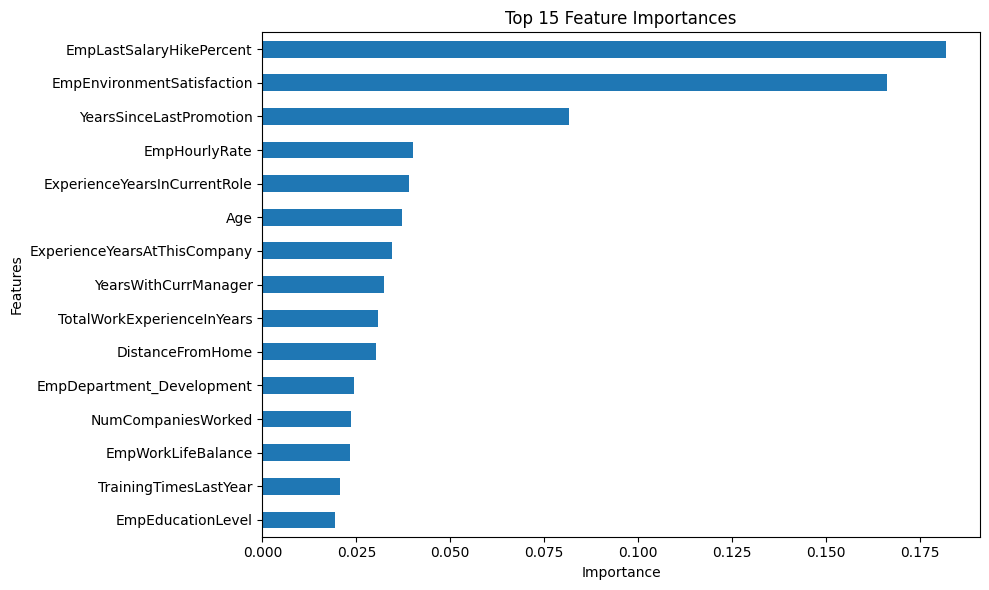

In [64]:
plt.figure(figsize=(10,6))
imp.head(15).sort_values().plot(kind='barh')
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

### Interpretation

* The results indicate that salary hike percentage, environment satisfaction, and promotion gap are the strongest drivers of employee performance.

# Summary
* After preprocessing and one-hot encoding, feature importance was calculated to identify the most influential variables affecting employee performance.

* A tree-based model (Random Forest) was used for feature importance because it:

  * Works well with both numerical and one-hot encoded categorical variables

  * Captures non-linear relationships

  * Provides a reliable importance ranking of predictors

* The top features were extracted and visualized to support the business objective of identifying key performance drivers.

* Results showed that performance is strongly influenced by:

  * Compensation and recognition (salary hike percentage)

  * Work environment satisfaction

  * Promotion gap (years since last promotion)

These insights were later used for recommendations and were also consistent with EDA findings.

# Model Creation

In [65]:
from sklearn.model_selection import train_test_split

X = df.drop('PerformanceRating', axis=1)
y = df['PerformanceRating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(960, 53) (240, 53)


# Model Comparision

In [66]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

results = []

# 1) Logistic Regression (Scaling required)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)

results.append(["LogisticRegression",
                accuracy_score(y_test, pred_lr),
                f1_score(y_test, pred_lr, average='macro')])

# 2) Random Forest (No scaling)
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

results.append(["RandomForest",
                accuracy_score(y_test, pred_rf),
                f1_score(y_test, pred_rf, average='macro')])

# 3) Gradient Boosting (No scaling)
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

results.append(["GradientBoosting",
                accuracy_score(y_test, pred_gb),
                f1_score(y_test, pred_gb, average='macro')])


# Display results

pd.DataFrame(results, columns=["Model","Accuracy","MacroF1"]).sort_values("Accuracy", ascending=False)

,Model,Accuracy,MacroF1
2,GradientBoosting,0.929167,0.885604
1,RandomForest,0.920833,0.871718
0,LogisticRegression,0.825000,0.717198


# Final Model Selection & Evaluation

In [67]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

final_model = GradientBoostingClassifier(random_state=42)
final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, final_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, final_pred))
print("\nClassification Report:\n", classification_report(y_test, final_pred))

Accuracy: 0.9291666666666667
Confusion Matrix:
 [[ 33   5   1]
 [  4 170   1]
 [  0   6  20]]

Classification Report:
               precision    recall  f1-score   support

           2       0.89      0.85      0.87        39
           3       0.94      0.97      0.96       175
           4       0.91      0.77      0.83        26

    accuracy                           0.93       240
   macro avg       0.91      0.86      0.89       240
weighted avg       0.93      0.93      0.93       240



# Summary
* Evaluated four models: Logistic Regression, Random Forest and Gradient Boosting.

* Performance metrics used: Accuracy and Macro F1-score (due to class imbalance).

* Gradient Boosting achieved the highest performance among all models.

* Logistic Regression performed significantly lower compared to tree-based models.

* Gradient Boosting was selected as the final model.

* It achieved the highest Accuracy (~ 93%) and highest Macro F1-score (~ 0.88).

* It provided better balance across performance classes (2, 3, 4).

* Confusion matrix showed most misclassifications occur between adjacent classes (2 ↔ 3 and 3 ↔ 4).

* Very few extreme misclassifications were observed.

* Overall model performance is strong and suitable for predicting employee performance levels.

# Model Dump

In [69]:
import joblib

joblib.dump(final_model, "employee_performance_model.pkl")
joblib.dump(list(X.columns), "model_features.pkl")

print("Model saved successfully.")

Model saved successfully.


# Conclusion
* This project analyzed employee performance data to identify the key factors influencing performance ratings.

* Exploratory analysis revealed that compensation, work environment satisfaction, and promotion gap significantly impact employee performance.

* Feature importance confirmed that:

  * EmpLastSalaryHikePercent

  * EmpEnvironmentSatisfaction

  * YearsSinceLastPromotion
* are the strongest performance drivers.

* Multiple machine learning models were evaluated, and Gradient Boosting achieved the highest accuracy (~93%) and best macro F1-score.

* The final model demonstrates strong predictive capability and can support HR in identifying performance trends and making data-driven decisions.

## Executive Summary

* This project analyzed employee performance factors at INX Future Inc.
Salary hike percentage, environment satisfaction, and promotion timing
were identified as the strongest performance drivers.

* Among multiple models evaluated, Gradient Boosting achieved the best performance
with approximately 93% accuracy and strong macro F1 score.

* The model can assist HR in identifying employees at risk of low performance
and support data-driven decision-making.

## Business Recommendations

1. Implement performance-linked salary hike policies.
2. Improve workplace environment through engagement initiatives.
3. Reduce promotion stagnation via structured career growth paths.
4. Monitor departments with higher low-performance rates.
5. Provide targeted development programs for employees with long role tenure.